In [1]:
import matplotlib.pyplot as plt
import numpy as np
from fractions import Fraction
from matplotlib.lines import Line2D

## Naive Quantum Zeno Effect

In [2]:
def P_ee(t,var,nu):
    return np.exp(-var * t / nu)

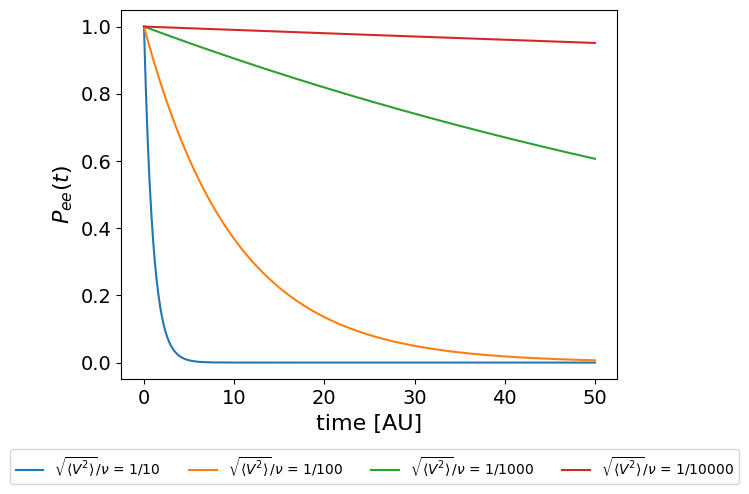

In [3]:
var = 100
nu = [100,1000,10000,100000]
t = np.linspace(0,50,500)


for i in nu:
    prob = P_ee(t,var,i)
    regime = np.sqrt(var)/i
    plt.plot(t,prob,label = r"$\sqrt{\langle V^2 \rangle} / \nu $ = " + str(Fraction(str(regime))))

plt.legend(ncol = 4, bbox_to_anchor = (1.26,-.17))
plt.xlabel("time [AU]",fontsize = 16)
plt.ylabel(r"$P_{ee}(t)$",fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.savefig("Figures/naive_QZE.pdf",bbox_inches = "tight")

## Zeno and Anti-Zeno via the Overlap Integral Formalism of Kofman and Kurizki

In [4]:
def F(w,wa,tau):
    arg = (w - wa)*tau/2
    return tau/(2*np.pi) * np.sinc(arg)**2

def G(w,A,B,d):
    return (A/((w-d)**2 + B**2))**2

def gaussian(omega0,omega,sigma):
    return np.exp(-(omega - omega0)**2 / (2*sigma**2))

def delta_integral(x0,x,f):
    diff = []
    for i in x:
        diff.append(abs(i-x0))

    value = np.where(diff == np.min(diff))[0][0]
    return f[value]

## Illustration of $F(\omega)$ broadening due to Energy-Time Uncertainity Principle

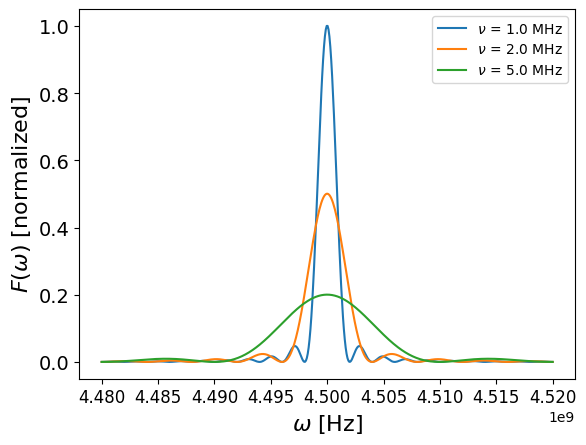

In [5]:
# set Hamiltonian

tau = 1/np.array([1e6,2e6,5e6])
omega = np.linspace(4.48,4.52,500)* 1e9
wa = 4.5 * 1e9

plt.xticks()

norm = max(F(omega,wa,tau[0]))
for i in tau:
    plt.plot(omega,F(omega,wa,i)/norm,label = r"$\nu$ = " + str(f"{1/i/1e6}") + " MHz")

plt.legend(fontsize = 13)
plt.legend(bbox_to_anchor = (1,1))
plt.xlabel("$\omega$ [Hz]",fontsize = 16)
plt.ylabel("$F(\omega)$ [normalized]",fontsize = 16)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 14)
plt.savefig("Figures/F_broadening.pdf",bbox_inches = "tight")

## Numerical Calculations of Overlap integrals to analyze the experimental results of Harrington et., al (2017)

In [6]:
## set up constants 
wa = 5.102e9  # center frequency
width = 15e6   # width
omega = np.linspace(wa - width/2, wa + width/2, 500)
ideal_sigma = 0.000001*1e9
bath_sigma = .0005*1e9

## Visualize Sweep of measurements across weighted bath spectrum for $\Gamma_m =$  1 MHz

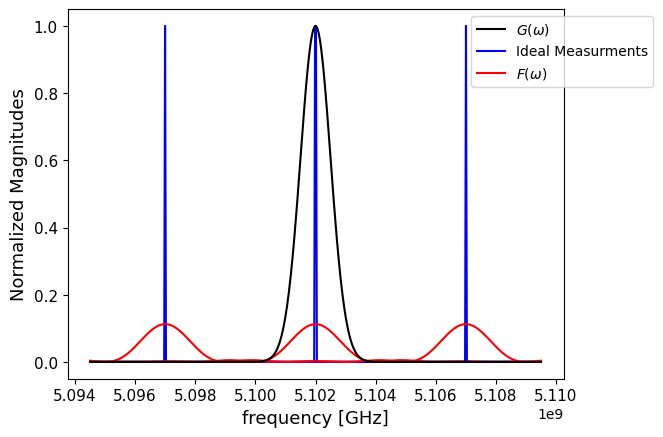

In [7]:
fig,ax = plt.subplots() 

nu = 1e6 # 1 MHz
tau = 1/nu

freq_sweep = np.linspace(-.005e9,.005e9,3)

resonant_ideal_measurement = F(omega,wa,1/1e4)
norm = np.max(resonant_ideal_measurement)
weighted_bath_spectrum = gaussian(wa,omega,bath_sigma)
weighted_bath_spectrum = weighted_bath_spectrum * norm

for f in freq_sweep:

     # take ideal measurement as some tight gaussian scaled to F(w) for visualization 
    ideal_measurement = gaussian(wa+f,omega,ideal_sigma)/np.max(gaussian(wa+f,omega,ideal_sigma)) * norm 
    
    transition_spectrum = F(omega,wa+f,tau) 
    transition_spectrum = transition_spectrum#/np.trapz(transition_spectrum) * norm_area

    plt.plot(omega,ideal_measurement/np.max(ideal_measurement),label = "Ideal Measurement",color = "blue")
    plt.plot(omega,transition_spectrum/np.max(ideal_measurement),label = r"$F(\omega)$",color = 'red')


# normalize to be around same height as ideal measurement
plt.plot(omega,weighted_bath_spectrum/norm,label = r"$G(\omega)$",color = 'black')

#plt.xlim(5.098e9,5.106e9)

legend_elements = [
    Line2D([0], [0], color='black',
           linestyle='-', markersize=8, label=r'$G(\omega)$'),
    Line2D([0], [0], color='blue',
           linestyle='-', markersize=8, label='Ideal Measurments'),
        Line2D([0], [0], color='red',
           linestyle='-', markersize=8, label='$F(\omega)$')
]

ax.legend(handles=legend_elements,bbox_to_anchor = (.8,1))
#plt.legend()

# Get the current tick locations and labels
# xvals = np.array([5.098, 5.099, 5.100, 5.101, 5.102, 5.103, 5.104, 5.105, 5.106])
# ax.set_xticks(xvals * 1e9)
# ax.set_xticklabels([f"{v:.3f}" for v in xvals])

plt.ylabel("Normalized Magnitudes",fontsize = 13)
plt.xlabel("frequency [GHz]",fontsize = 13)
ax.tick_params("x",labelsize = 11)
ax.tick_params("y",labelsize = 11)
plt.savefig("Figures/example_sweep_harrington_analysis.pdf",bbox_inches = "tight")

## Numerically calculate overlap integrals to get effective decay rates for various detunings

In [8]:
freq_sweep = np.linspace(-.005e9,.005e9,51)

### $\Gamma_m =$ 1 MHz

In [9]:
nu = 1e6 # 1 MHz
tau = 1/nu

resonant_ideal_measurement = F(omega,wa,1/1e4)
norm = np.max(resonant_ideal_measurement)
weighted_bath_spectrum = gaussian(wa,omega,bath_sigma)
weighted_bath_spectrum = weighted_bath_spectrum * norm

deltaR_1MHz = [] 

for f in freq_sweep:

    # this is for visualization, when integrating to find R we 
    ideal_measurement = gaussian(wa+f,omega,ideal_sigma)/np.max(gaussian(wa+f,omega,ideal_sigma)) * norm  
    
    transition_spectrum = F(omega,wa+f,tau) 
    transition_spectrum = transition_spectrum#/np.trapz(transition_spectrum) * norm_area
    
    I_ideal = delta_integral(wa+f,omega,weighted_bath_spectrum) #np.trapz(ideal_measurement*weighted_bath_spectrum)
    I_ETUP = np.trapz(transition_spectrum * weighted_bath_spectrum, x=omega)

    deltaR_1MHz.append((I_ideal - I_ETUP))

### $\Gamma_m =$ 2 MHz

In [10]:
nu = 2e6 # 1 MHz
tau = 1/nu

resonant_ideal_measurement = F(omega,wa,1/1e4)
norm = np.max(resonant_ideal_measurement)
weighted_bath_spectrum = gaussian(wa,omega,bath_sigma)
weighted_bath_spectrum = weighted_bath_spectrum * norm

deltaR_2MHz = [] 

for f in freq_sweep:

    # this is for visualization, when integrating to find R we 
    ideal_measurement = gaussian(wa+f,omega,ideal_sigma)/np.max(gaussian(wa+f,omega,ideal_sigma)) * norm  
    
    transition_spectrum = F(omega,wa+f,tau) 
    transition_spectrum = transition_spectrum#/np.trapz(transition_spectrum) * norm_area
    
    I_ideal = delta_integral(wa+f,omega,weighted_bath_spectrum) #np.trapz(ideal_measurement*weighted_bath_spectrum)
    I_ETUP = np.trapz(transition_spectrum * weighted_bath_spectrum, x=omega)

    deltaR_2MHz.append((I_ideal - I_ETUP))

## Plot $R_0 - R$ vs qubit-bath detuning 

Zeno effect is observed when $R_0 - R > 0$ and Anti-Zeno Effect is observed when $R_0 - R < 0$

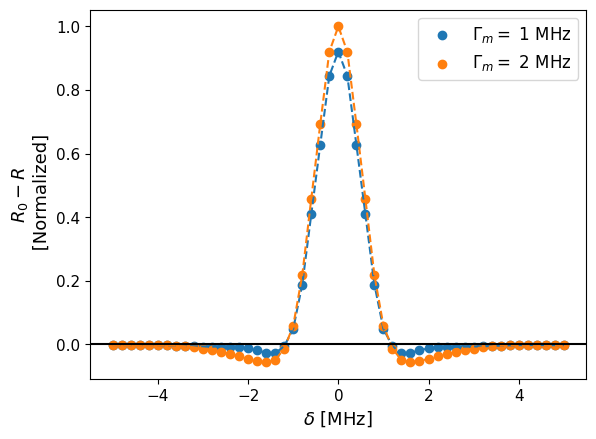

In [11]:
fig,ax = plt.subplots()
plt.scatter(freq_sweep/1e6,deltaR_1MHz/np.max(deltaR_2MHz),label = "$\Gamma_m =$ 1 MHz")
plt.plot(freq_sweep/1e6,deltaR_1MHz/np.max(deltaR_2MHz),linestyle = 'dashed')

plt.scatter(freq_sweep/1e6,deltaR_2MHz/np.max(deltaR_2MHz),label = "$\Gamma_m =$ 2 MHz")
plt.plot(freq_sweep/1e6,deltaR_2MHz/np.max(deltaR_2MHz),linestyle = 'dashed')

xlims = ax.get_xlim()
plt.hlines(0,xlims[0],xlims[1],color = 'black')
plt.xlim(xlims[0],xlims[1])

plt.ylabel(r"$R_0 - R$" + "\n [Normalized]",fontsize = 13)
plt.xlabel("$\delta$ [MHz]",fontsize = 13)
ax.tick_params("x",labelsize = 11)
ax.tick_params("y",labelsize = 11)
plt.legend(fontsize = 12)
plt.savefig("Figures/RminusR0.pdf",bbox_inches = "tight")